In [1]:
import numpy
import pandas

import matplotlib.pyplot as plt
plt.style.use('mystyle.mplstyle')

import sbruceana

In [2]:
PATH_TO_SBRUCE = "/Users/triozzi/Analysis/nuedis/checks/data/cc1e0pi/"

#### Pre-selection

After the not-clear-cosmic cut, vertex in fiducial volume cuts. 
Before the flash matching cut. Decide on triggering or non-triggering.


In [3]:
FILE_CV = "preselection/CNAF_CV_1eNp0pi_NuMI_NoSysts_Preselection.root"
FILE_OFFBEAM = "preselection/CNAF_OffBeam_1eNp0pi_NuMI_NoSysts_Preselection_GainFix.root"
FILE_DATA = "preselection/CNAF_Data_1eNp0pi_NuMI_NoSysts_Preselection_GainFix.root"

In [4]:
# MC
df = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_CV}",
  "events/selectedNu"  
)
pot = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_CV}")

df_cos = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_CV}",
  "events/selectedCos"  
)
pot_cos = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_CV}")

df_cos['cosmic'] = 1
df = pandas.concat(
  (df, df_cos)
)

# data
df_data = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_DATA}",
  "events/selectedData"  
)
pot_data = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_DATA}")
time_data = sbruceana.utils.get_livetime_data(f"{PATH_TO_SBRUCE}{FILE_DATA}")

# offbeam
df_offbeam = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_OFFBEAM}",
  "offbeam/selectedOffbeam"  
)
time_offbeam = sbruceana.utils.get_livetime_offbeam(f"{PATH_TO_SBRUCE}{FILE_OFFBEAM}")

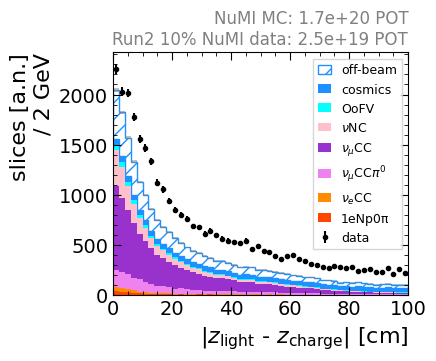

In [5]:
fig, ax = plt.subplots(figsize=(4.25, 3.5), layout='constrained')

var = "deltaZ_Trigger"
width = 2; bins = numpy.arange(0., 100+width, width)

ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data/time_offbeam, yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)

# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = '|$z_\\mathrm{light}$ - $z_\\mathrm{charge}$| [cm]',
  ylabel = f'slices [a.n.]\n/ {width} GeV',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=9); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig(f"plots/preselection/preselection_{var}.pdf", dpi=300)

/var/folders/j_/p25pntkj5wb56cfcr5f3blr00000gn/T/ipykernel_35062/3678565430.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(fontsize=8.5)


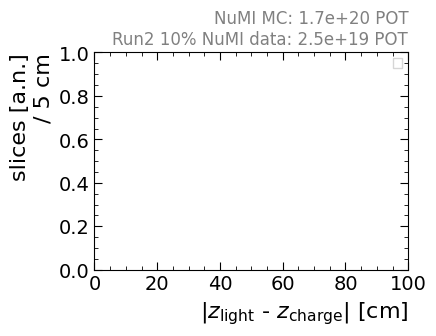

In [6]:
fig, ax = plt.subplots(figsize=(4.25, 3.25), layout='constrained')

var = "deltaZ_Trigger"

width = 5; bins = numpy.arange(0., 100+width, width)

# ax = sbruceana.plotting.plot_by_category(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, True, True)
# ax = sbruceana.plotting.plot_data(ax, df_data, bins, var)

# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = '|$z_\\mathrm{light}$ - $z_\\mathrm{charge}$| [cm]',
  ylabel = f'slices [a.n.]\n/ {width} cm',
  xlim   = (bins[0], bins[-1]),
)
# leg = ax.legend(fontsize=9.5, title='NuMI CV'); leg.get_title().set_fontsize(10)
leg = ax.legend(fontsize=8.5)

plt.show()
fig.savefig(f"plots/preselection/preselection_{var}.pdf", dpi=300)

#### Electron identification

After identifying a shower particle with NuGraph2, plot its shower energy on Collection with no cuts.

#### Electron quality cuts

After cutting on the energy >200 MeV, show the quality of the leading shower along with the cuts.

In [7]:
FILE_CV = "preselection_electron/CNAF_CV_1eNp0pi_NuMI_NoSysts_Preselectionelectron.root"
FILE_OFFBEAM = "preselection_electron/CNAF_OffBeam_1eNp0pi_NuMI_NoSysts_PreselectionElectron_GainFix.root"
FILE_DATA = "preselection_electron/CNAF_Data_1eNp0pi_NuMI_NoSysts_Preselectionelectron_GainFix.root"

In [8]:
# MC
df = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_CV}",
  "events/selectedNu"  
)
pot = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_CV}")

df_cos = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_CV}",
  "events/selectedCos"  
)
pot_cos = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_CV}")

df_cos['cosmic'] = 1
df = pandas.concat(
  (df, df_cos)
)

# data
df_data = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_DATA}",
  "events/selectedData"  
)
pot_data = sbruceana.utils.get_POT(f"{PATH_TO_SBRUCE}{FILE_DATA}")
time_data = sbruceana.utils.get_livetime_data(f"{PATH_TO_SBRUCE}{FILE_DATA}")

# offbeam
df_offbeam = sbruceana.io.convert_tree_to_df(
  f"{PATH_TO_SBRUCE}{FILE_OFFBEAM}",
  "offbeam/selectedOffbeam"  
)
time_offbeam = sbruceana.utils.get_livetime_offbeam(f"{PATH_TO_SBRUCE}{FILE_OFFBEAM}")

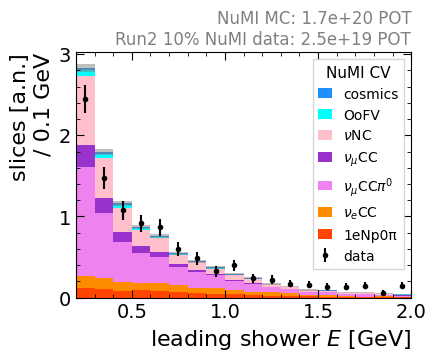

In [9]:
fig, ax = plt.subplots(figsize=(4.25, 3.5), layout='constrained')

var = "collE"
width = 0.1; bins = numpy.arange(0.2, 2+width, width)

ax = sbruceana.plotting.plot_by_category(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, 1, 1, True, True)
ax = sbruceana.plotting.plot_data(ax, df_offbeam, bins, var, True)

# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'leading shower $E$ [GeV]',
  ylabel = f'slices [a.n.]\n/ {width} GeV',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=10, title='NuMI CV'); leg.get_title().set_fontsize(11)

plt.show()

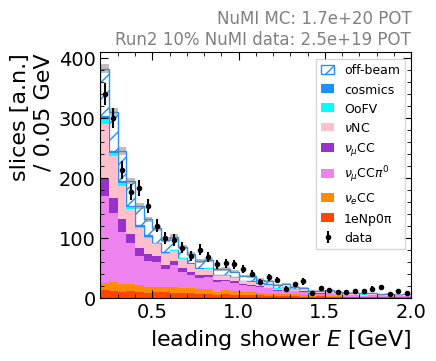

In [10]:
fig, ax = plt.subplots(figsize=(4.25, 3.5), layout='constrained')

var = "collE"
width = 0.05; bins = numpy.arange(0.2, 2+width, width)

ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data/time_offbeam, yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)

# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'leading shower $E$ [GeV]',
  ylabel = f'slices [a.n.]\n/ {width} GeV',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=9); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig(f"plots/preselection/preselection_electron_{var}.pdf", dpi=300)

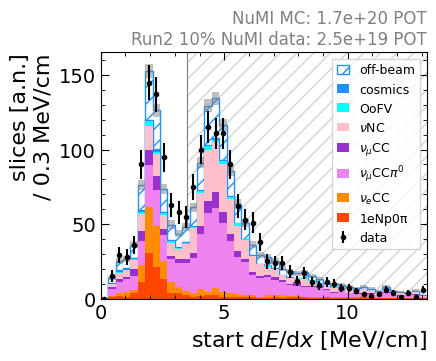

In [11]:
fig, ax = plt.subplots(figsize=(4.25, 3.5), layout='constrained')

var = "colldEdx"

width = 0.3; bins = numpy.arange(0., 13+width, width)

ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data*1.14, bins, var, False)

ax = sbruceana.plotting.place_cut(ax, 3.5, True)

# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'start d$E$/d$x$ [MeV/cm]',
  ylabel = f'slices [a.n.]\n/ {width} MeV/cm',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=9); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig(f"plots/preselection/preselection_electron_{var}.pdf", dpi=300)

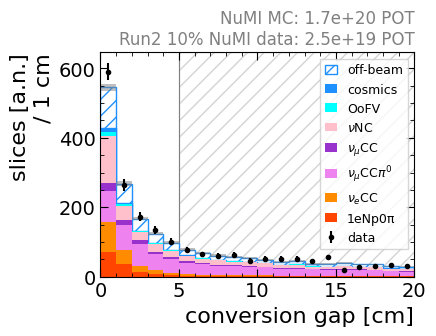

In [12]:
fig, ax = plt.subplots(figsize=(4.25, 3.25), layout='constrained')

var = "convgap"

width = 1; bins = numpy.arange(0., 20+width, width)

ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)

ax = sbruceana.plotting.place_cut(ax, 5, True)

# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'conversion gap [cm]',
  ylabel = f'slices [a.n.]\n/ {width} cm',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(ncol=1, fontsize=9); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig(f"plots/preselection/preselection_electron_{var}.pdf", dpi=300)

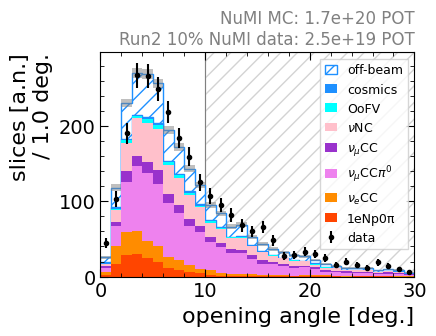

In [13]:
fig, ax = plt.subplots(figsize=(4.25, 3.25), layout='constrained')

var = "openangle"

width = 1.; bins = numpy.arange(0., 30+width, width)

ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)

ax = sbruceana.plotting.place_cut(ax, 10, True)


# gfx
ax.set(
  title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'opening angle [deg.]',
  ylabel = f'slices [a.n.]\n/ {width} deg.',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=9); leg.get_title().set_fontsize(11)

plt.show()
fig.savefig(f"plots/preselection/preselection_electron_{var}.pdf", dpi=300)

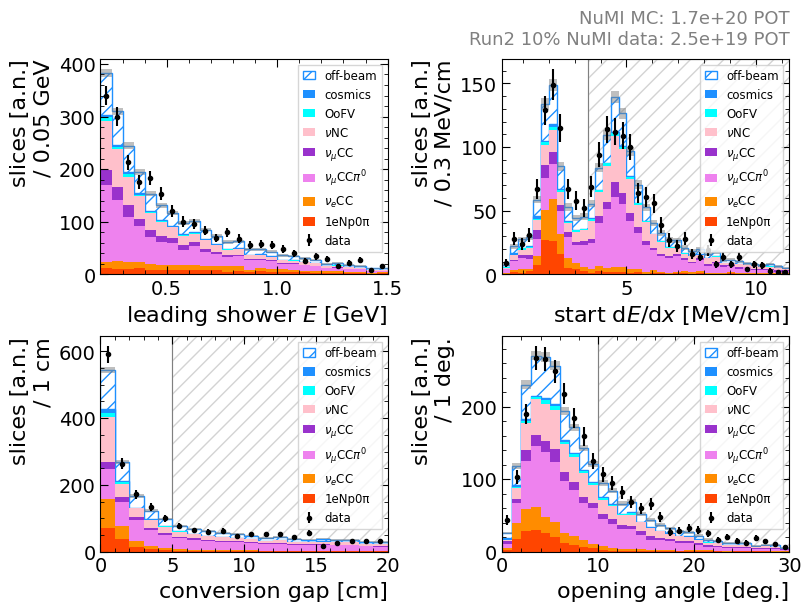

In [14]:
fig, axes = plt.subplots(figsize=(4*2, 3*2), ncols=2, nrows=2, layout='constrained')

# shower energy
ax = axes[0, 0]

var = "collE"
width = 0.05; bins = numpy.arange(0.2, 1.5+width, width)
ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)

# gfx
ax.set(
  # title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'leading shower $E$ [GeV]',
  ylabel = f'slices [a.n.]\n/ {width} GeV',
  xlim   = (bins[0], bins[-1]),
)
# leg = ax.legend(fontsize=9, title='NuMI CV'); leg.get_title().set_fontsize(9.5)
leg = ax.legend(fontsize=8.5)

# dEdx
ax = axes[0, 1]

var = "colldEdx"
width = 0.3; bins = numpy.arange(0.2, 11.2+width, width)
ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data*1.14, bins, var, False)
ax = sbruceana.plotting.place_cut(ax, 3.5, True)

# gfx
ax.set(
  # title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'start d$E$/d$x$ [MeV/cm]',
  ylabel = f'slices [a.n.]\n/ {width} MeV/cm',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=8.5)

# gap
ax = axes[1, 0]

var = "convgap"
width = 1; bins = numpy.arange(0., 20+width, width)
ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)
ax = sbruceana.plotting.place_cut(ax, 5, True)

# gfx
ax.set(
  # title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'conversion gap [cm]',
  ylabel = f'slices [a.n.]\n/ {width} cm',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=8.5)

# opening angle
ax = axes[1, 1]

var = "openangle"
width = 1; bins = numpy.arange(0., 30+width, width)
ax = sbruceana.plotting.plot_by_category_with_offbeam(ax, df, sbruceana.config.CC1E0PI_CATEGORIES, bins, var, df_offbeam, offbeam_scale=time_data / time_offbeam , yscale=pot_data/pot, area_normalized=False, band=True, clip=False)
ax = sbruceana.plotting.plot_data(ax, df_data, bins, var, False)
ax = sbruceana.plotting.place_cut(ax, 10, True)

# gfx
ax.set(
  # title = f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT',
  xlabel = 'opening angle [deg.]',
  ylabel = f'slices [a.n.]\n/ {width} deg.',
  xlim   = (bins[0], bins[-1]),
)
leg = ax.legend(fontsize=8.5)

fig.suptitle(f'NuMI MC: {pot:.1e} POT\nRun2 10% NuMI data: {pot_data:.1e} POT', x=0.98, ha='right', fontsize=13, c='gray')
# fig.suptitle(f'After electron-ID', x=0.02, ha='left', fontsize=13, c='black')

plt.show()
fig.savefig(f"plots/preselection/preselection_electron.pdf", dpi=300)

#### Proton identification

After identifying N protons, show for example the number of protons, and the momentum of the leading protons.

Then, explain reason behind vetos, and show final neutrino properties.

Eventually, calibrate energies.